In [1]:
using NeutralAtoms
using DataFrames
using CSV
using Plots  

Error budget of rydberg oscillations
First, load the config file

In [2]:
include("../conf/default.jl")
cfg_rydb, _ = get_default_configs();

We can run get_rydberg_error_budget() function, but this will calculate all error contributions on single process, for faster calculations you can spread samples across processes and average density matrix in **err_bdgt_distr.jl** file, which saves it in **err_bdgt.jld2** file that you can read using JLD2

In [ ]:
infids = get_rydberg_error_budget(cfg_rydb, n_samples = 300);

In [ ]:
using NeutralAtoms
infids = load_with_JLD2("data\\err_bdgt.jld2")

Dict{Any, Any} with 10 entries:
  "Intermdeiate state decay" => 0.0125226
  "Doppler"                  => 0.000392191
  "Laser noise"              => 0.000404877
  "xyz_motion"               => 0.00269404
  "Total"                    => 0.0142452
  "Rydberg state decay"      => 0.000868822
  "z_motion"                 => 0.00271257
  "Atom motion"              => 0.00277394
  "Intermdeiate propability" => 0.000392191
  "xy_motion"                => 0.000517219

In [22]:
function plot_rydberg_err_bdgt(infidelities; 
    dir_name="data\\",     file_name="rydb_errs.png",
    title="Error budget for 2π rydberg pulse",    blue=true)

    red_color  = RGBA(207.0/255, 71.0/255, 80.0/255, 1.0)
    blue_color = RGBA(135.0/255,203.0/255,230.0/255,1.0)
    if blue
        color = blue_color 
    else 
        color = red_color
    end

    keys_iF   = collect(keys(infidelities))
    keys_ordered = ["Total","Laser noise","Atom motion","xy_motion",
         "z_motion","xyz_motion","Doppler", "Intermdeiate propability",
         "Intermdeiate state decay","Rydberg state decay"]

    keys_final = [key for key in keys_ordered if key in keys_iF]
    #values_final = [100 * infidelities[key] for key in keys_ordered if key in keys_iF]
    values_final = [(key=="Intermdeiate propability") ? 100 * infidelities[key] : 100*(infidelities[key]-infidelities["Intermdeiate propability"])
     for key in keys_ordered if key in keys_iF]

    p = bar(keys_final, values_final;
    xrotation=45,    margin=10Plots.mm,
    ylabel="Infidelity, %",     title=title,
    label=nothing,    dpi=300,    size=(600, 550),
    xguidefontsize = 14,    yguidefontsize = 14,
    xtickfontsize = 14,    ytickfontsize = 14,
    color=color    )

    savefig("$(dir_name)$(file_name)")
    display(p)
    return keys_final, values_final
end;

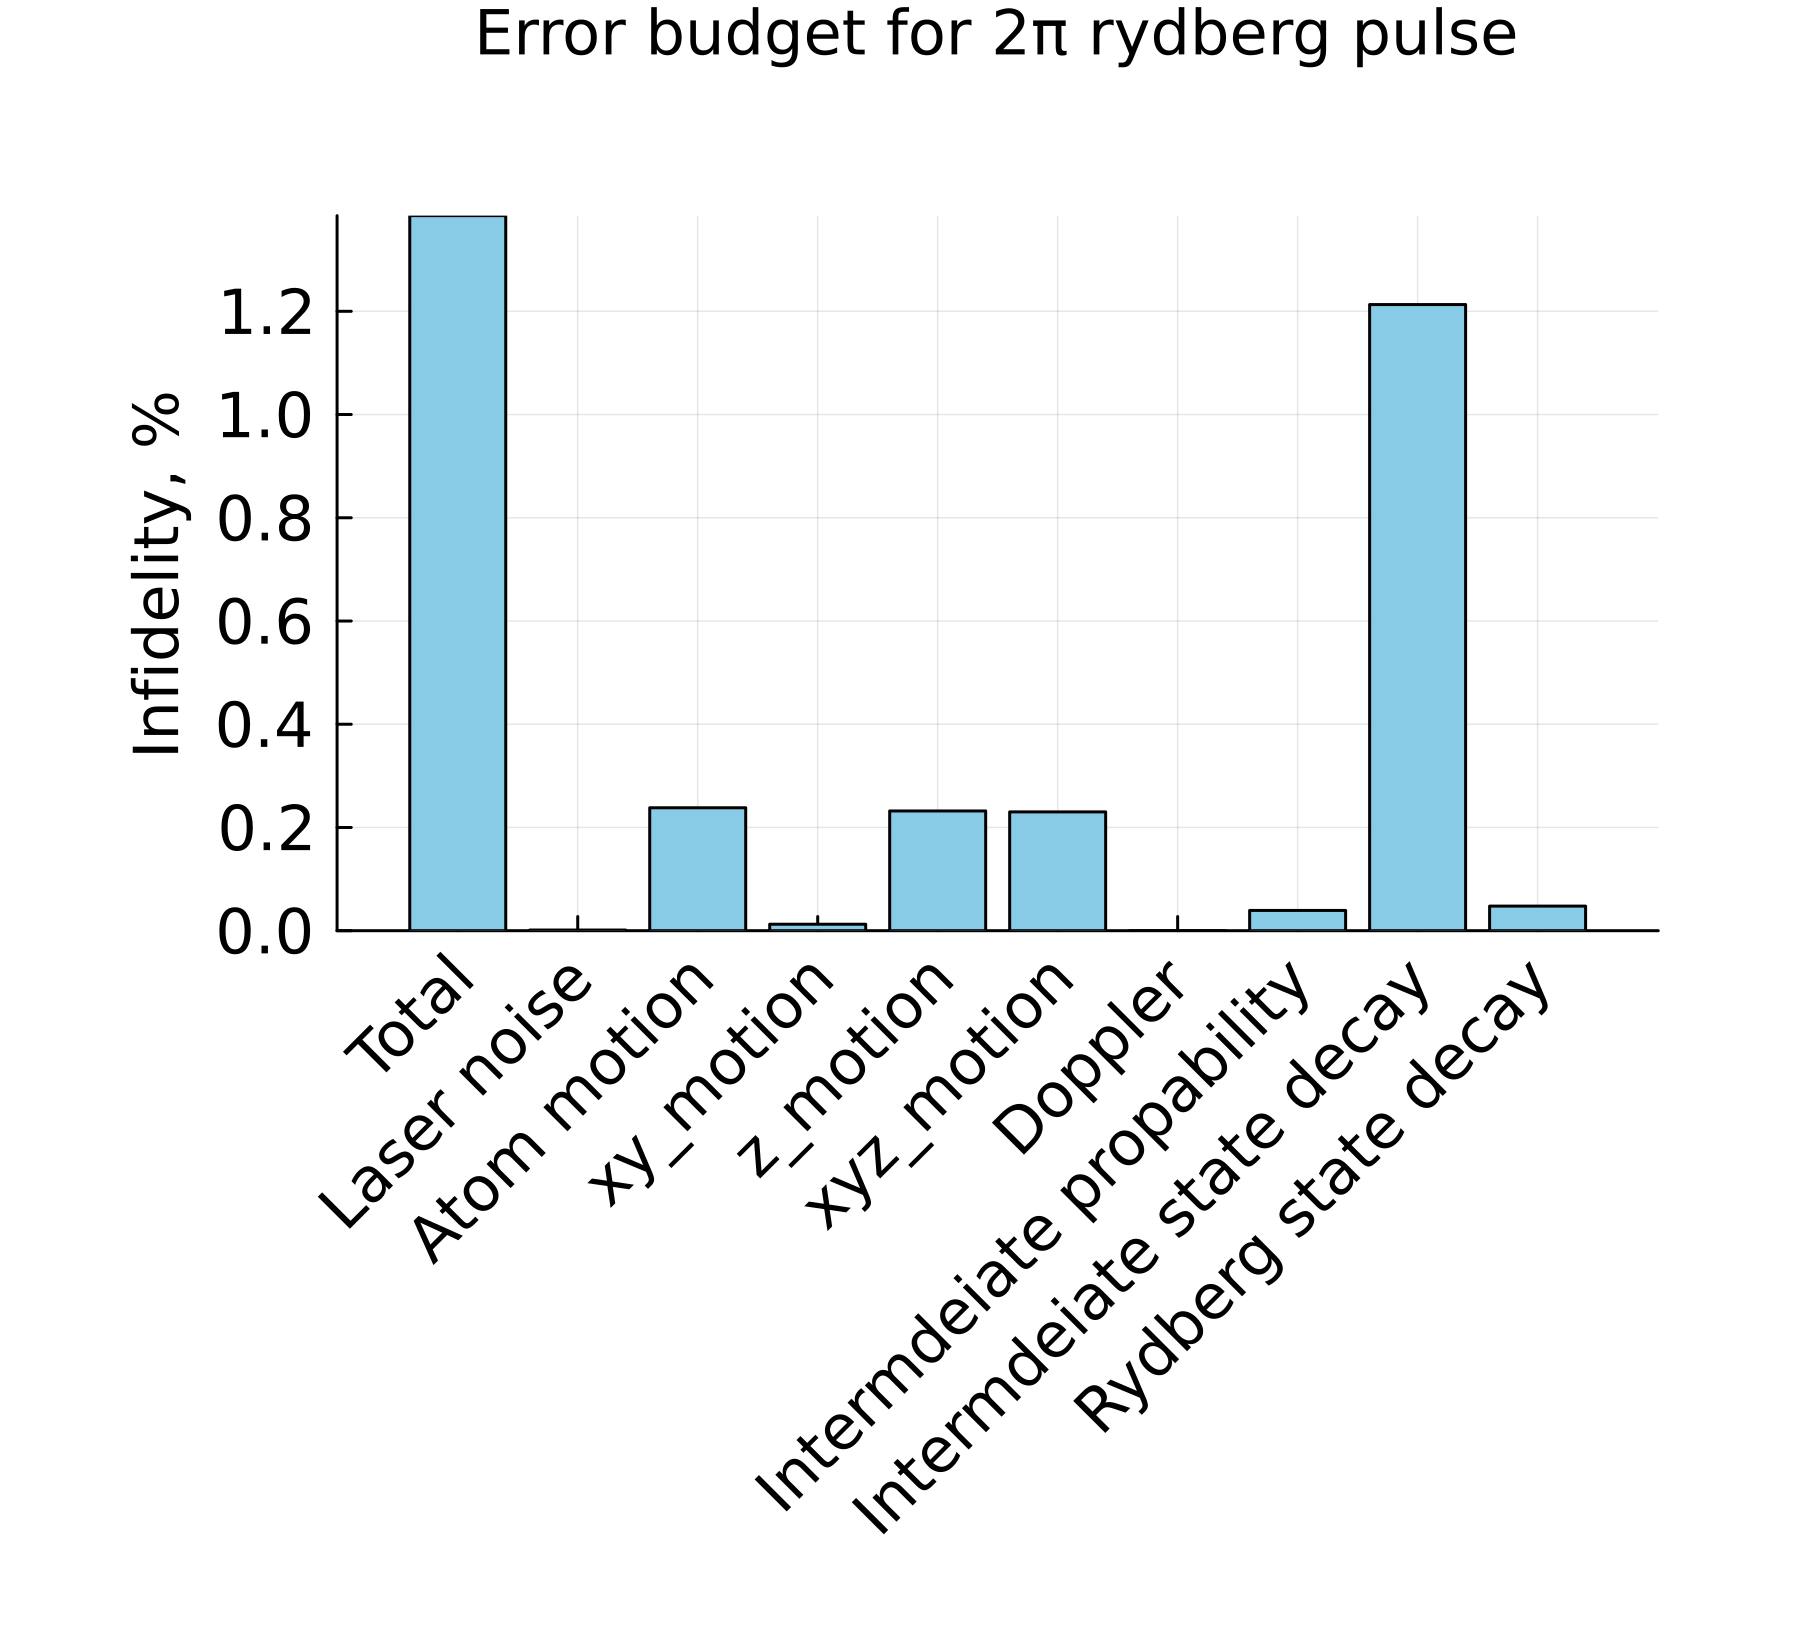

In [23]:
plot_rydberg_err_bdgt(infids);

Now let's study more complicated laser beams

Rydberg oscillations in flattop field

In [7]:
include("../conf/default.jl")
c_xy = get_default_cxy();
cfg_HG, _ = get_default_configs();
cfg_HG.second_laser_params["type"] = "flattop_HG" #"gauss" #
cfg_HG.second_laser_params["coeffs_xy"] = c_xy;
cfg_HG.n_samples = 200; #

In [8]:
cfg_HG.second_laser_params 

Dict{String, Any} with 7 entries:
  "coeffs_xy" => [1.19061 -0.00432629 … -3.30497e-14 -2.58291e-15; 0.013834 0.0…
  "z0"        => 26.4555
  "n_sg"      => 1
  "θ"         => 0.0
  "w0"        => 2.0
  "Ω"         => 301.331
  "type"      => "flattop_HG"

Target atoms

In [9]:
shifts = [[0.,1.7,0.],[0.,-1.7,0.]]
file_names = ["output17.csv","output_17.csv"]
dir_name = "data\\" ;

0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:05<Inf:Inf, InfGs/it]
1.0%┣▌                                             ┫ 2/200 [00:10<33:35, 10s/it]
1.5%┣▊                                              ┫ 3/200 [00:15<24:52, 8s/it]
2.0%┣█                                              ┫ 4/200 [00:19<21:09, 6s/it]
2.5%┣█▏                                             ┫ 5/200 [00:23<19:00, 6s/it]
3.0%┣█▍                                             ┫ 6/200 [00:27<17:39, 5s/it]
3.5%┣█▋                                             ┫ 7/200 [00:31<16:44, 5s/it]
4.0%┣█▉                                             ┫ 8/200 [00:35<16:05, 5s/it]
4.5%┣██▏                                            ┫ 9/200 [00:39<15:33, 5s/it]
5.0%┣██▎                                           ┫ 10/200 [00:43<15:08, 5s/it]
5.5%┣██▌                                           ┫ 11/200 [00:47<14:46, 5s/it]
6.0%┣██▊                    

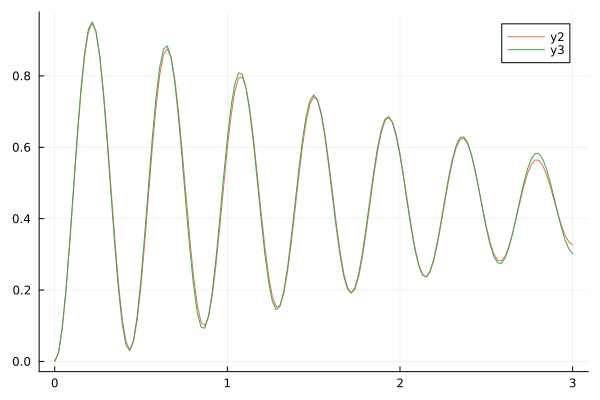

In [10]:
plot([0.0],[0.0], label="") 
for i in 1:length(shifts)
    cfg_HG.shift = shifts[i]
    ρ_mean = simulation(cfg_HG)[1]
    Pr_HG = real(expect(ket_r ⊗ dagger(ket_r), ρ_mean));  
    data = DataFrame(Column1 = cfg_HG.tspan, Column2 = Pr_HG)
    CSV.write(dir_name * file_names[i], data) 
    plot!(cfg_HG.tspan, Pr_HG) ;
end
plot!([0.0],[0.0], label="") 

Crosstalk on non-target atoms in flattop field 

In [ ]:
cfg_HG.n_samples = 3;

In [19]:
shifts = [[0.,5.1,0.],[0.,-5.1,0.],[3.4,1.7, 0.],[3.4,-1.7, 0.],[-3.4,1.7, 0.],[-3.4,-1.7, 0.]]
file_names = ["output51.csv","output_51.csv", "output3417.csv", "output34_17.csv","output_3417.csv","output_34_17.csv"]
dir_name = "data\\" ;

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:06<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:06<Inf:Inf, InfGs/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:06<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:06<Inf:Inf, InfGs/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:05<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:05<Inf:Inf, InfGs/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:05<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:05<Inf:Inf, InfGs/it]
0.0%┣                       

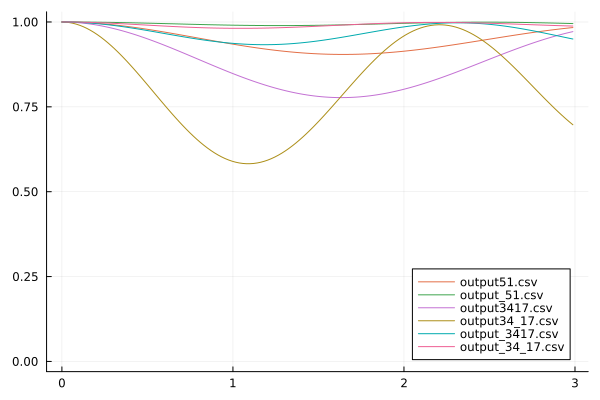

In [ ]:
plot([0.0],[0.0], label="") 
for i in 1:length(shifts)
    cfg_HG.shift = shifts[i]
    ρ_mean = simulation(cfg_HG)[1]
    Pr_HG = 1.0 .- real(expect(ket_r ⊗ dagger(ket_r), ρ_mean));  
    data = DataFrame(Column1 = cfg_HG.tspan, Column2 = Pr_HG)
    CSV.write(dir_name * file_names[i], data) 
    plot!(cfg_HG.tspan, Pr_HG, label = file_names[i]) ;
end

In [ ]:
plot!([0.0],[0.0], label="")

____________________________________

In [ ]:
"""     function corr_detun(shift, cfg)
        d0 = cfg.detuning_params[1]
        dict = cfg.blue_laser_params
        lsr_prms = [dict["Ω"], dict["w0"], dict["z0"]]
        E0 = reconstruct_HG_field_2d(0.0,0.0,0.0, lsr_prms, c_xy)
        E = reconstruct_HG_field_2d(shift[1],shift[2],shift[3], lsr_prms, c_xy)
        #cfg.detuning_params = [d0, (abs(E)^2-abs(E0)^2)/(4*d0)]
        println("Ω = ", real(E) * lsr_prms[1]/(4π*d0)/2π, ", Δ = ", (abs(E)^2-abs(E0)^2)/(4*d0)/2π)
        return (abs(E)^2-abs(E0)^2)/(4*d0)
    end;
    shift = [3.4, -1.7, 0.] 
    d_for_atom = 2π * 0.2
    d = corr_detun(shift, cfg_HG)
    d0 = cfg_HG.detuning_params[1]
    #(abs(E)^2-abs(E0)^2)/(4*d0)]
    cfg_HG.detuning_params[2] += 2π*0.03 #d_for_atom
"""